In [3]:
# import libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller

from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
# read in met data from CB01 station (TxSON TOA5 format)
# skiprows=9: 5 citation header lines + 4 TOA5 header lines (equipment, col names, units, sample type)
df = pd.read_csv('../../datasets/TxSON_data_2026-02-24/CB01_met.dat',
                 skiprows=9, header=None,
                 names=['Date', 'Record', 'Ppt', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'ETos', 'Rso'],
                 parse_dates=['Date'], index_col='Date')
df = df[['Ppt', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad']]

In [5]:
# CB01_met.dat covers 2022-06-08 to 2024-03-19; start from first complete month
df = df[df.index >= "2022-07-01"]

In [6]:
# # Replace inf values and Fill nan values
# df.replace([np.inf, -np.inf], np.nan, inplace=True)
# df.fillna(df.mean(), inplace=True)

# df

In [7]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [8]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [9]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [10]:
# view head of data frame
df.head(10)

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2022-07-31,0.054282,29.462325,56.087272,2.003003,186.014294,313.646888
2022-08-31,0.138621,27.428481,67.124086,1.595422,167.308977,247.169543
2022-09-30,0.064914,25.246917,64.880569,0.898026,163.204860,245.719667
2022-10-31,0.030390,20.063550,57.068024,1.419464,163.927609,195.915478
2022-11-30,0.147111,12.648853,75.691236,1.414031,141.356825,113.582108
2022-12-31,0.007511,10.685509,71.217849,1.325577,153.226535,96.781528
2023-01-31,0.022191,11.944788,60.170148,1.815874,165.961999,128.313460
2023-02-28,0.024190,12.157204,63.774702,2.087140,154.517292,161.699440
2023-03-31,0.040632,16.872461,63.987742,2.263882,155.370120,197.238468


In [11]:
# Verify shape of data frame
df.shape

(21, 6)

## Visualization 

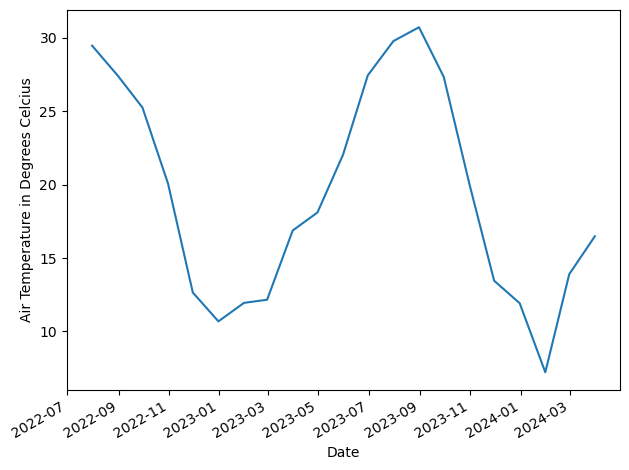

In [12]:
# Visualize Tair Montly Data for 2015
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature in Degrees Celcius')


fig.autofmt_xdate()
plt.tight_layout()



## Exploration 

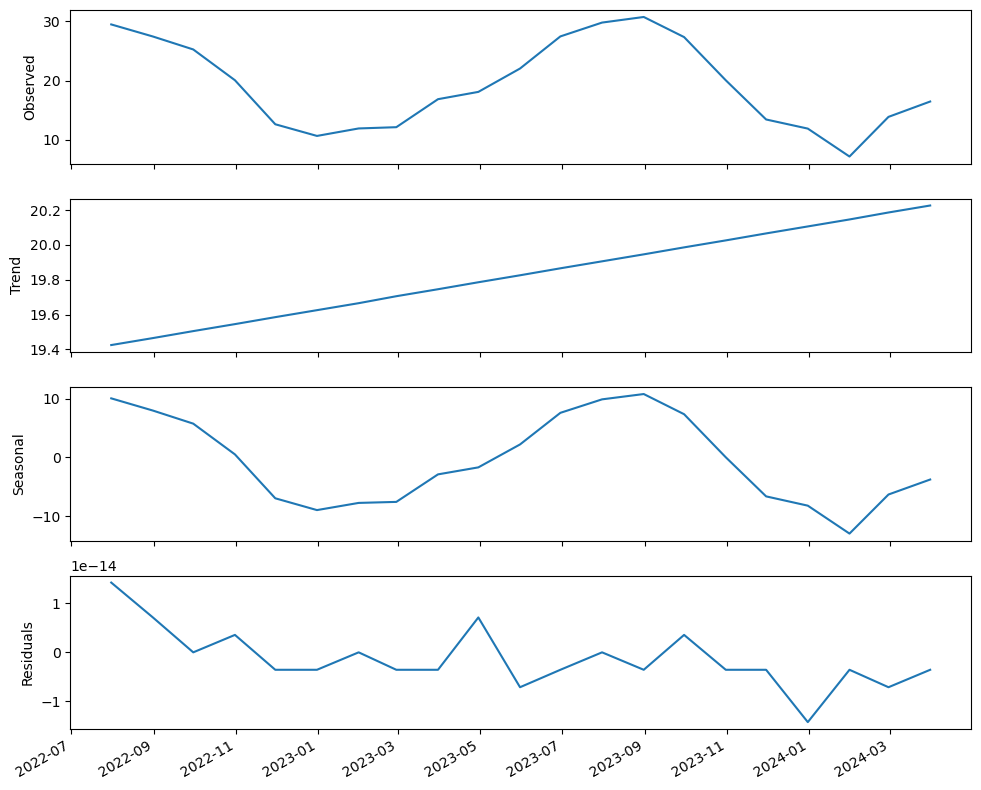

In [13]:
# Decompose data to view seasonality, trend, and residuals
# period=12 for yearly seasonality in monthly data
decomposition = STL(df.Tair, period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

fig.autofmt_xdate()
plt.tight_layout()

## Modeling 

In [14]:
# Preform Ad Fuller Test to check for stationarity
ad_fuller_result = adfuller(df.Tair)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.6065156672784746
p-value: 0.0916580753122449


In [15]:
# Difference Data and check Ad Fuller test again
Tair_diff = np.diff(df.Tair, n=1)

ad_fuller_result = adfuller(Tair_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -6.20431883992748
p-value: 5.706562133384307e-08


### Train/test split 

In [16]:
# CB01_met.dat: 2022-07 to 2024-03 = 21 months after resampling
train_len = 17
test_len = 4
total_len = 21

train = df.Tair[:train_len]
test = df.Tair[train_len:]

test

Date
2023-12-31    11.919335
2024-01-31     7.216531
2024-02-29    13.893394
2024-03-31    16.479045
Freq: ME, Name: Tair, dtype: float64

In [17]:
# incorporate exog data
exog = df.Srad[:train_len]

exog_full = np.empty([total_len, 5])
exog_full[:, 0] = df.Ppt
exog_full[:, 1] = df.RH
exog_full[:, 2] = df.Windspeed
exog_full[:, 3] = df.Winddirection
exog_full[:, 4] = df.Srad

### SARIMA(p,0,q)(P,0,Q)<sub>12<sub> 

In [18]:
# Define SARIMA model
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [19]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12

In [20]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(train, exog, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), np.float64(81.45063475479897)]
[(0, 0, 0, 1), np.float64(81.78838442474371)]
[(0, 0, 1, 0), np.float64(81.75463164004071)]
[(0, 0, 1, 1), np.float64(83.7546306871552)]
[(0, 1, 0, 0), np.float64(77.44817510114899)]
[(0, 1, 0, 1), np.float64(78.80447973757514)]
[(0, 1, 1, 0), np.float64(78.80447922325216)]
[(0, 1, 1, 1), np.float64(80.804479679001)]
[(1, 0, 0, 0), np.float64(74.70463771722585)]
[(1, 0, 0, 1), np.float64(76.33323136478882)]
[(1, 0, 1, 0), np.float64(76.3342238226645)]
[(1, 0, 1, 1), np.float64(78.3337530357911)]
[(1, 1, 0, 0), np.float64(76.61211903229875)]
[(1, 1, 0, 1), np.float64(78.30425565447982)]
[(1, 1, 1, 0), np.float64(78.30514083034788)]
[(1, 1, 1, 1), np.float64(80.30471373109368)]


,"(p,q,P,Q)",AIC
0,"(1, 0, 0, 0)",74.704638
1,"(1, 0, 0, 1)",76.333231
2,"(1, 0, 1, 0)",76.334224
3,"(1, 1, 0, 0)",76.612119
4,"(0, 1, 0, 0)",77.448175
5,"(1, 1, 0, 1)",78.304256
6,"(1, 1, 1, 0)",78.305141
7,"(1, 0, 1, 1)",78.333753
8,"(0, 1, 1, 0)",78.804479
9,"(0, 1, 0, 1)",78.804480


In [21]:
# Define and fit SARIMAX model (use s=12 for yearly seasonality in monthly data)
SARIMA_model = SARIMAX(train, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], 12), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Tair   No. Observations:                   17
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -44.694
Date:                Tue, 16 Jun 2026   AIC                             93.389
Time:                        11:56:16   BIC                             94.934
Sample:                    07-31-2022   HQIC                            93.468
                         - 11-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9400      0.046     20.603      0.000       0.851       1.029
sigma2        15.6259      8.215      1.902      0.057      -0.475      31.727
Ljung-Box (L1) (Q):                   8.32   Jarque-

## Forecasting 

In [22]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'last_season':
        pred_last_season = []
        
        
        for i in range(train_len, total_len, window):
            last_season = df.Tair[i-window:i]
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.Tair[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], 12), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [23]:
pred_df = df[train_len:]

pred_df

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2023-12-31,0.053253,11.919335,67.512177,1.341589,172.244711,118.790906
2024-01-31,0.058720,7.216531,67.973777,1.648918,137.122317,116.961272
2024-02-29,0.058761,13.893394,66.174397,1.818769,171.741871,153.647500
2024-03-31,0.028798,16.479045,73.650567,1.700943,151.001574,174.690392


In [24]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len / 3)

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df.last_season

Date
2023-12-31    13.455264
2024-01-31    11.919335
2024-02-29     7.216531
2024-03-31    13.893394
Freq: ME, Name: last_season, dtype: float64

In [25]:
# Define SARIMA Prediction Dataframe
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df.SARIMA

Date
2023-12-31    13.227469
2024-01-31    11.720144
2024-02-29     7.082961
2024-03-31    13.640179
Freq: ME, Name: SARIMA, dtype: float64

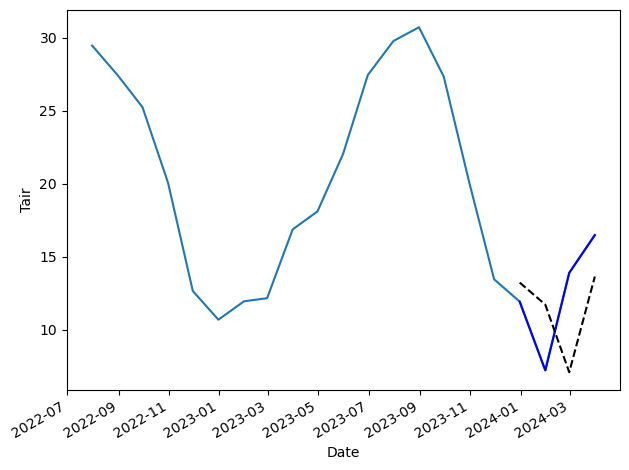

In [26]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.plot(pred_df.Tair, 'b-', label='actual')
# ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Tair')

fig.autofmt_xdate()
plt.tight_layout()



## Evaluate 

In [27]:
mse=np.mean((pred_df.Tair-pred_df.SARIMA)**2)
mse

np.float64(19.108724565189323)